In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

In [183]:
import os

print(os.listdir('/content'))

['.config', 'WA_Fn-UseC_-Telco-Customer-Churn.csv', 'Untitled6 (1).ipynb', 'histogram.png', 'WA_Fn-UseC_-Telco-Customer-Churn.zip', 'drive', 'cleaned_data.csv', 'scatter_plot.png', 'line_plot.png', 'correlation_heatmap.png', 'bar_chart.png', 'box_plot.png', 'sample_data']


In [184]:
import zipfile
import os

zip_path = "/content/WA_Fn-UseC_-Telco-Customer-Churn.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

print(os.listdir("/content"))

['.config', 'WA_Fn-UseC_-Telco-Customer-Churn.csv', 'Untitled6 (1).ipynb', 'histogram.png', 'WA_Fn-UseC_-Telco-Customer-Churn.zip', 'drive', 'cleaned_data.csv', 'scatter_plot.png', 'line_plot.png', 'correlation_heatmap.png', 'bar_chart.png', 'box_plot.png', 'sample_data']


In [185]:
import pandas as pd

df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [186]:
# Missing values count
missing_count = df.isnull().sum()

# Missing percentage
missing_percentage = (missing_count / len(df)) * 100

# Summary table
missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

print(missing_df)

                  Missing Count  Missing Percentage
customerID                    0                 0.0
gender                        0                 0.0
SeniorCitizen                 0                 0.0
Partner                       0                 0.0
Dependents                    0                 0.0
tenure                        0                 0.0
PhoneService                  0                 0.0
MultipleLines                 0                 0.0
InternetService               0                 0.0
OnlineSecurity                0                 0.0
OnlineBackup                  0                 0.0
DeviceProtection              0                 0.0
TechSupport                   0                 0.0
StreamingTV                   0                 0.0
StreamingMovies               0                 0.0
Contract                      0                 0.0
PaperlessBilling              0                 0.0
PaymentMethod                 0                 0.0
MonthlyCharg

In [187]:
high_missing = missing_df[missing_df["Missing Percentage"] > 20]

print(high_missing)

Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []


In [188]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    missing_percent = (df[col].isnull().sum() / len(df)) * 100

    if 0 < missing_percent < 20:
        df[col] = df[col].fillna(df[col].median())

print("Numeric missing values filled successfully.")

Numeric missing values filled successfully.


In [189]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [190]:
# Task 3: Duplicate Detection and Removal

# Count duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# Store shape before removing duplicates
rows_before = df.shape[0]

# Remove duplicates
df = df.drop_duplicates()

# Store shape after removing duplicates
rows_after = df.shape[0]

# Number of rows removed
rows_removed = rows_before - rows_after
print("Rows removed:", rows_removed)

# Check null percentage after removing duplicates
null_percentage_after = (df.isnull().sum() / len(df)) * 100

print("\nNull Percentage After Removing Duplicates:")
print(null_percentage_after)

Number of duplicate rows: 0
Rows removed: 0

Null Percentage After Removing Duplicates:
customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64


In [191]:
# Task 4: Data Type Correction

# Check current data types
print("Data Types Before Conversion:\n")
print(df.dtypes)

# Memory usage before conversion
memory_before = df.memory_usage(deep=True).sum()
print("\nMemory Usage Before:", memory_before, "bytes")

# Convert TotalCharges from object to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Convert a repetitive string column to category
df['Contract'] = df['Contract'].astype('category')

# Check data types after conversion
print("\nData Types After Conversion:\n")
print(df.dtypes)

# Memory usage after conversion
memory_after = df.memory_usage(deep=True).sum()
print("\nMemory Usage After:", memory_after, "bytes")

print("\nMemory Saved:", memory_before - memory_after, "bytes")

Data Types Before Conversion:

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Memory Usage Before: 7152287 bytes

Data Types After Conversion:

customerID            object
gender                object
SeniorCitizen          int64
Partner               object
Dependents            object
tenure                 int64
PhoneService          object
MultipleLines         object
InternetService       object
OnlineSecurity        object
OnlineBack

In [192]:
# Task 5: Descriptive Statistics and Skewness

# Descriptive statistics
print("Descriptive Statistics:")
print(df.describe())

# Calculate skewness
print("\nSkewness of Numeric Columns:")

skewness = df.select_dtypes(include=['number']).skew()

print(skewness)

# Column with highest absolute skewness
highest_skew_col = skewness.abs().idxmax()

print("\nColumn with Highest Absolute Skewness:", highest_skew_col)
print("Skewness Value:", skewness[highest_skew_col])

Descriptive Statistics:
       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7032.000000
mean        0.162147    32.371149       64.761692   2283.300441
std         0.368612    24.559481       30.090047   2266.771362
min         0.000000     0.000000       18.250000     18.800000
25%         0.000000     9.000000       35.500000    401.450000
50%         0.000000    29.000000       70.350000   1397.475000
75%         0.000000    55.000000       89.850000   3794.737500
max         1.000000    72.000000      118.750000   8684.800000

Skewness of Numeric Columns:
SeniorCitizen     1.833633
tenure            0.239540
MonthlyCharges   -0.220524
TotalCharges      0.961642
dtype: float64

Column with Highest Absolute Skewness: SeniorCitizen
Skewness Value: 1.8336327440928564


In [193]:
# Task 6: Outlier Detection using IQR

numeric_cols = ['tenure', 'MonthlyCharges']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\nColumn: {col}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower)
    print("Upper Bound:", upper)
    print("Number of Outliers:", len(outliers))


Column: tenure
Q1: 9.0
Q3: 55.0
IQR: 46.0
Lower Bound: -60.0
Upper Bound: 124.0
Number of Outliers: 0

Column: MonthlyCharges
Q1: 35.5
Q3: 89.85
IQR: 54.349999999999994
Lower Bound: -46.02499999999999
Upper Bound: 171.375
Number of Outliers: 0


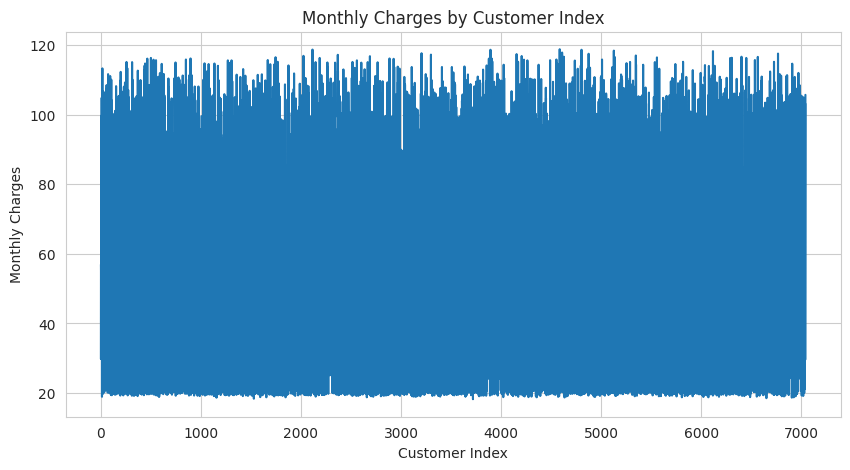

In [194]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df.index, df['MonthlyCharges'])
plt.title("Monthly Charges by Customer Index")
plt.xlabel("Customer Index")
plt.ylabel("Monthly Charges")
plt.grid(True)

plt.savefig("line_plot.png")
plt.show()

/tmp/ipykernel_2385/1858008410.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Contract')['MonthlyCharges'].mean().plot(kind='bar')


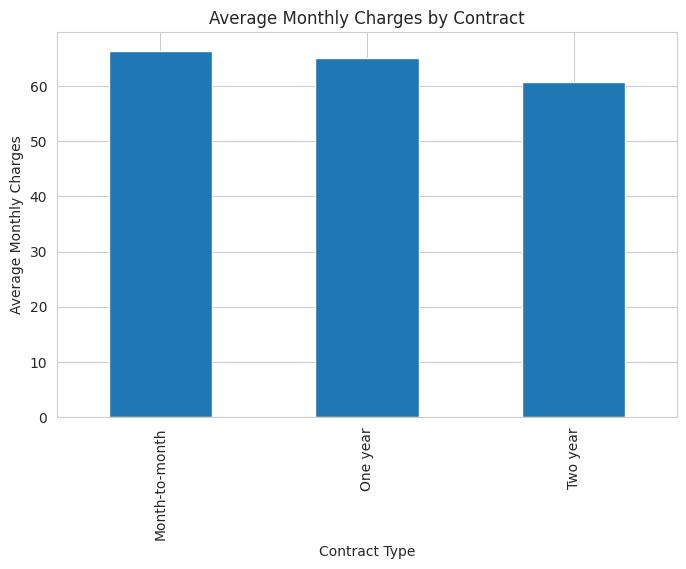

In [195]:
plt.figure(figsize=(8,5))

df.groupby('Contract')['MonthlyCharges'].mean().plot(kind='bar')

plt.title("Average Monthly Charges by Contract")
plt.xlabel("Contract Type")
plt.ylabel("Average Monthly Charges")

plt.savefig("bar_chart.png")
plt.show()

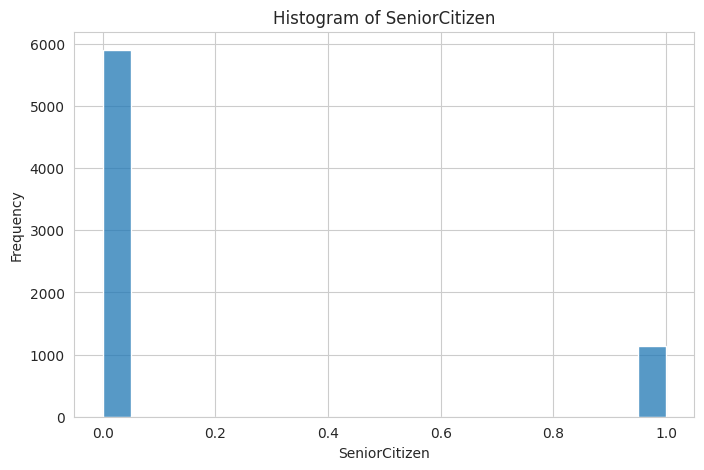

In [196]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df['SeniorCitizen'], bins=20)

plt.title("Histogram of SeniorCitizen")
plt.xlabel("SeniorCitizen")
plt.ylabel("Frequency")

plt.savefig("histogram.png")
plt.show()

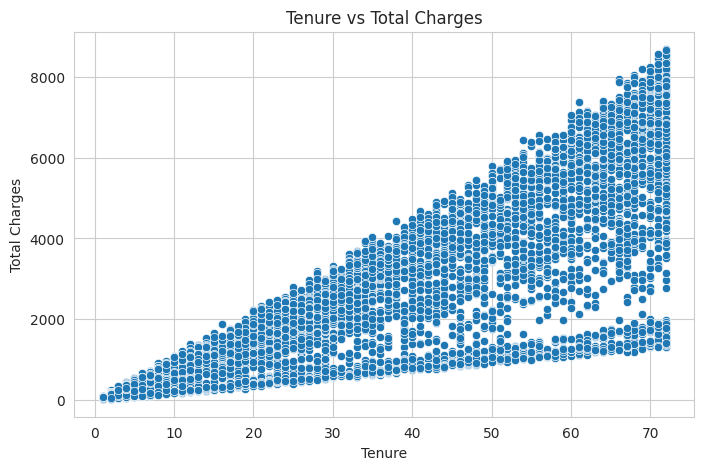

In [197]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x='tenure', y='TotalCharges')

plt.title("Tenure vs Total Charges")
plt.xlabel("Tenure")
plt.ylabel("Total Charges")

plt.savefig("scatter_plot.png")
plt.show()

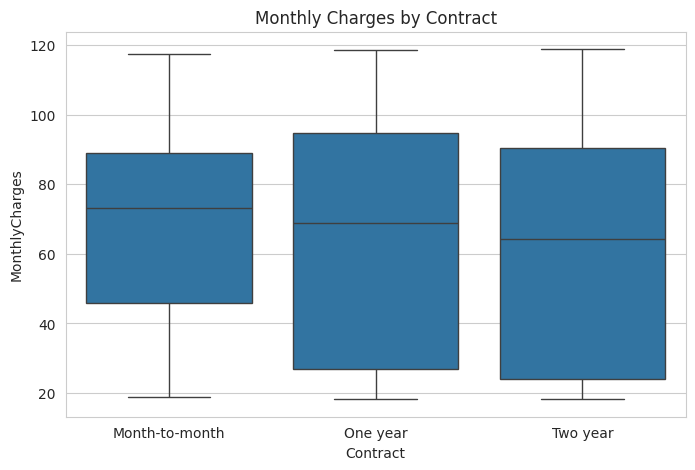

In [198]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='Contract', y='MonthlyCharges')

plt.title("Monthly Charges by Contract")

plt.savefig("box_plot.png")
plt.show()

Correlation Matrix:
                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.016567        0.220173      0.102411
tenure               0.016567  1.000000        0.247900      0.825880
MonthlyCharges       0.220173  0.247900        1.000000      0.651065
TotalCharges         0.102411  0.825880        0.651065      1.000000

Highest Correlation Pair: ('tenure', 'TotalCharges')
Correlation Value: 0.8258804609332019


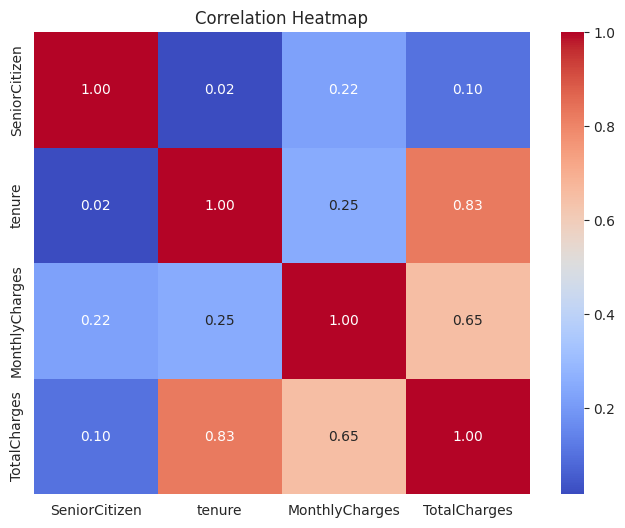

In [199]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Pearson Correlation Matrix
correlation_matrix = numeric_df.corr()

print("Correlation Matrix:")
print(correlation_matrix)

# Find the highest absolute correlation (excluding self-correlation)
corr_copy = correlation_matrix.abs().copy()

# Remove diagonal values
import numpy as np
np.fill_diagonal(corr_copy.values, 0)

highest_pair = corr_copy.stack().idxmax()
highest_value = corr_copy.stack().max()

print("\nHighest Correlation Pair:", highest_pair)
print("Correlation Value:", highest_value)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png")
plt.show()

In [200]:
# Task 9(a)

# Get the two most skewed numeric columns
skewness = df.select_dtypes(include='number').skew().abs()
top2_cols = skewness.sort_values(ascending=False).head(2).index

print("Top 2 Most Skewed Columns:", list(top2_cols))

for col in top2_cols:
    print(f"\nColumn: {col}")
    print("Mean :", df[col].mean())
    print("Median :", df[col].median())

    # Fill any remaining missing values using median
    df[col] = df[col].fillna(df[col].median())

print("\nRemaining Null Values:")
print(df[top2_cols].isnull().sum())

Top 2 Most Skewed Columns: ['SeniorCitizen', 'TotalCharges']

Column: SeniorCitizen
Mean : 0.1621468124378816
Median : 0.0

Column: TotalCharges
Mean : 2283.3004408418656
Median : 1397.475

Remaining Null Values:
SeniorCitizen    0
TotalCharges     0
dtype: int64


In [201]:
# Pearson Correlation
pearson = df.select_dtypes(include='number').corr()

# Spearman Correlation
spearman = df.select_dtypes(include='number').corr(method='spearman')

print("Pearson Correlation:")
print(pearson)

print("\nSpearman Correlation:")
print(spearman)

difference = (spearman - pearson).abs()

print("\nDifference Matrix:")
print(difference)

print("\nTop 3 Differences:")

top3 = (
    difference.where(~np.eye(difference.shape[0], dtype=bool))
    .stack()
    .sort_values(ascending=False)
    .drop_duplicates()
    .head(3)
)

print(top3)

Pearson Correlation:
                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.016567        0.220173      0.102652
tenure               0.016567  1.000000        0.247900      0.825464
MonthlyCharges       0.220173  0.247900        1.000000      0.650864
TotalCharges         0.102652  0.825464        0.650864      1.000000

Spearman Correlation:
                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.018556        0.221067      0.107256
tenure               0.018556  1.000000        0.276417      0.886998
MonthlyCharges       0.221067  0.276417        1.000000      0.637475
TotalCharges         0.107256  0.886998        0.637475      1.000000

Difference Matrix:
                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        0.000000  0.001989        0.000893      0.004604
tenure               0.001989  0.000000        0.028517      0.061534
MonthlyCharges       0.000

In [202]:
group = df.groupby("Contract")["MonthlyCharges"].agg(["mean", "std", "count"])

print(group)

highest_mean = group["mean"].idxmax()
highest_std = group["std"].idxmax()

print("\nHighest Mean Group:", highest_mean)
print("Highest Std Group:", highest_std)

ratio = group["mean"].max() / group["mean"].min()

print("Mean Ratio:", ratio)

                     mean        std  count
Contract                                   
Month-to-month  66.398490  26.926599   3875
One year        65.048608  31.840539   1473
Two year        60.770413  34.678865   1695

Highest Mean Group: Month-to-month
Highest Std Group: Two year
Mean Ratio: 1.0926121292797855


/tmp/ipykernel_2385/2834069958.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby("Contract")["MonthlyCharges"].agg(["mean", "std", "count"])


In [203]:
df.to_csv("cleaned_data.csv", index=False)

print("cleaned_data.csv has been saved successfully!")

cleaned_data.csv has been saved successfully!


In [204]:
# Part 2: Exploratory Data Analysis (EDA)

In [205]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [206]:
## 2.1 Churn Distribution

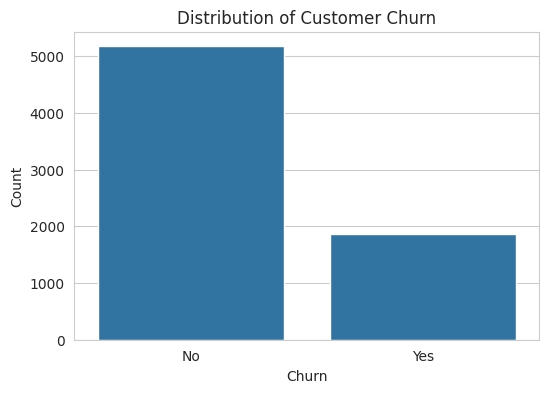

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [207]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)

plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

print(df['Churn'].value_counts())
print("\nPercentage:")
print(df['Churn'].value_counts(normalize=True)*100)

In [208]:
## 2.2 Gender vs Churn

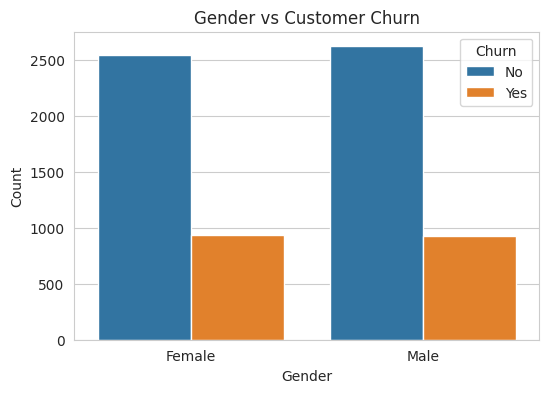

In [209]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='Churn', data=df)

plt.title("Gender vs Customer Churn")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

In [210]:
## 2.3 Senior Citizen vs Churn

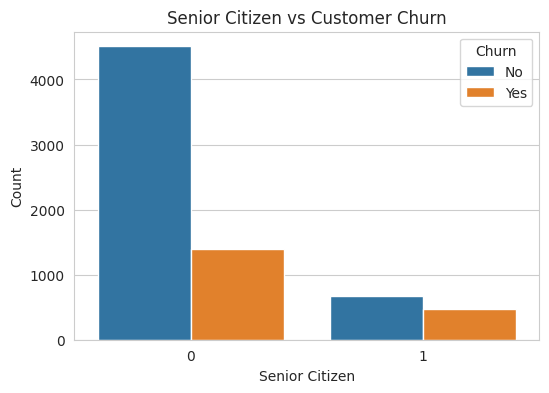

In [211]:
plt.figure(figsize=(6,4))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)

plt.title("Senior Citizen vs Customer Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Count")

plt.show()

In [212]:
## 2.4 Contract Type vs Churn

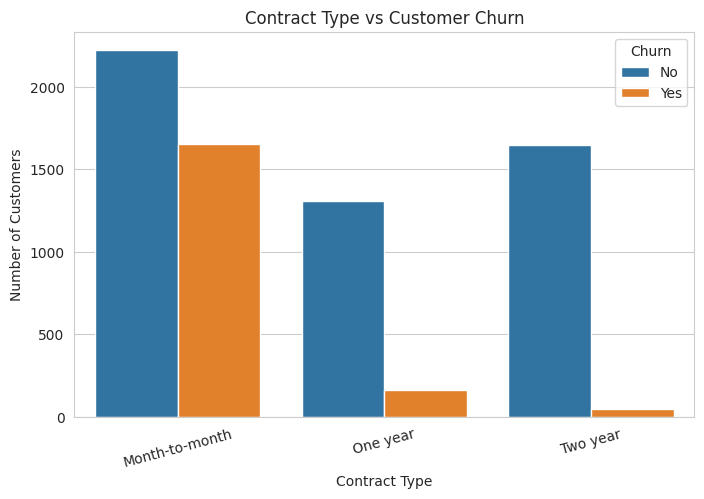

In [213]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)

plt.show()

In [214]:
## 2.5 Payment Method vs Churn

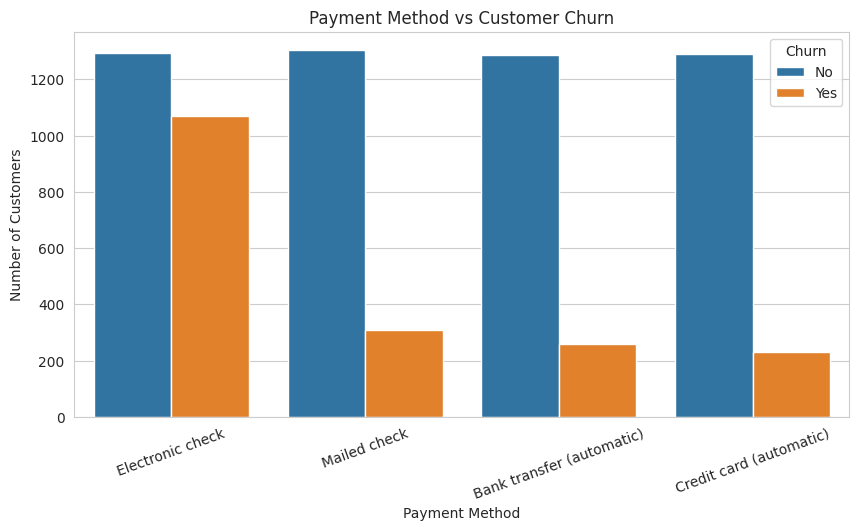

In [215]:
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)

plt.title("Payment Method vs Customer Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.show()

In [216]:
## 2.6 Internet Service vs Churn

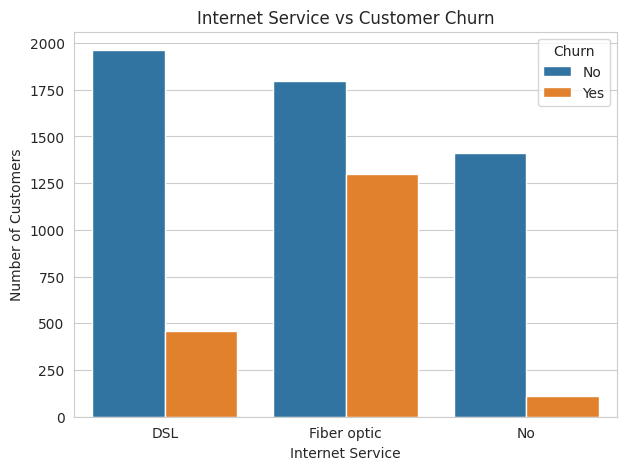

In [217]:
plt.figure(figsize=(7,5))
sns.countplot(x='InternetService', hue='Churn', data=df)

plt.title("Internet Service vs Customer Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

In [218]:
## 2.7 Distribution of Tenure

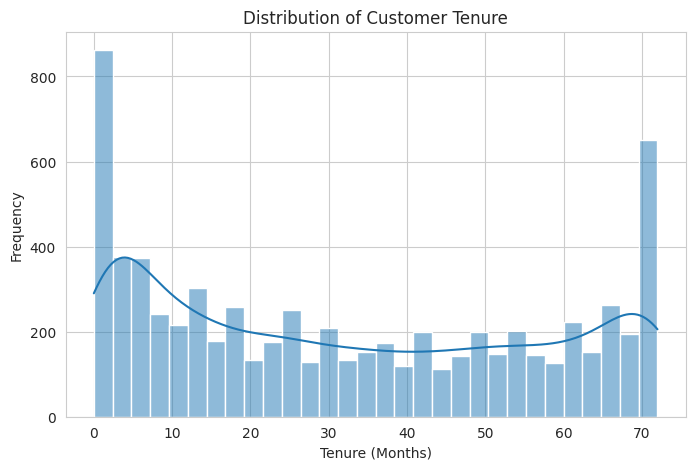

In [219]:
plt.figure(figsize=(8,5))
sns.histplot(df['tenure'], bins=30, kde=True)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Frequency")

plt.show()

In [220]:
## 2.8 Distribution of Monthly Charges

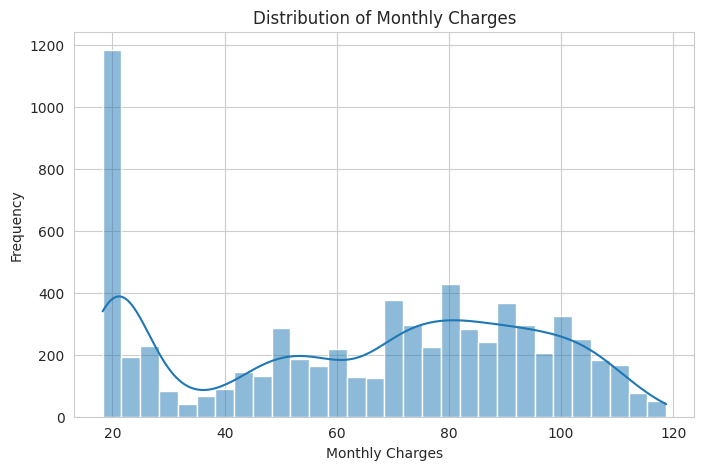

In [221]:
plt.figure(figsize=(8,5))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

plt.show()

In [222]:
## 2.9 Distribution of Total Charges

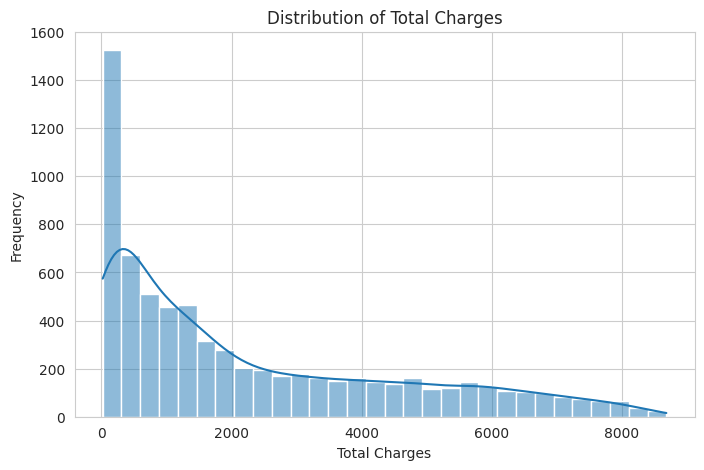

In [223]:
plt.figure(figsize=(8,5))
sns.histplot(df['TotalCharges'].dropna(), bins=30, kde=True)

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Frequency")

plt.show()

In [224]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   object  
 1   gender            7043 non-null   object  
 2   SeniorCitizen     7043 non-null   int64   
 3   Partner           7043 non-null   object  
 4   Dependents        7043 non-null   object  
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   object  
 7   MultipleLines     7043 non-null   object  
 8   InternetService   7043 non-null   object  
 9   OnlineSecurity    7043 non-null   object  
 10  OnlineBackup      7043 non-null   object  
 11  DeviceProtection  7043 non-null   object  
 12  TechSupport       7043 non-null   object  
 13  StreamingTV       7043 non-null   object  
 14  StreamingMovies   7043 non-null   object  
 15  Contract          7043 non-null   category
 16  PaperlessBilling  7043 n

In [225]:
## 2.10 Correlation Heatmap

In [226]:
# Part 2: Supervised Machine Learning

In [227]:
## 3.1 Define Features and Targets

In [228]:
# Feature Matrix
X = df.drop(columns=['MonthlyCharges'])

# Regression Target
y_reg = df['MonthlyCharges']

# Classification Target
y_clf = (y_reg > y_reg.median()).astype(int)

print("Feature Matrix Shape:", X.shape)
print("Regression Target Shape:", y_reg.shape)
print("Classification Target Distribution:")
print(y_clf.value_counts())

Feature Matrix Shape: (7043, 20)
Regression Target Shape: (7043,)
Classification Target Distribution:
MonthlyCharges
0    3528
1    3515
Name: count, dtype: int64


In [229]:
# Part 2: Supervised Machine Learning
## 3.1 Define Features and Targets

In [230]:
# Feature Matrix
X = df.drop(columns=['MonthlyCharges'])

# Regression Target
y_reg = df['MonthlyCharges']

# Binary Classification Target
y_clf = (y_reg > y_reg.median()).astype(int)

print("Feature Matrix Shape:", X.shape)
print("Regression Target Shape:", y_reg.shape)
print("\nClassification Target Distribution:")
print(y_clf.value_counts())

Feature Matrix Shape: (7043, 20)
Regression Target Shape: (7043,)

Classification Target Distribution:
MonthlyCharges
0    3528
1    3515
Name: count, dtype: int64


In [231]:
print(X.dtypes)

customerID            object
gender                object
SeniorCitizen          int64
Partner               object
Dependents            object
tenure                 int64
PhoneService          object
MultipleLines         object
InternetService       object
OnlineSecurity        object
OnlineBackup          object
DeviceProtection      object
TechSupport           object
StreamingTV           object
StreamingMovies       object
Contract            category
PaperlessBilling      object
PaymentMethod         object
TotalCharges         float64
Churn                 object
dtype: object


In [232]:
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [233]:
# Feature Matrix
X = df.drop(columns=['MonthlyCharges'])

# Regression Target
y_reg = df['MonthlyCharges']

# Classification Target
y_clf = (y_reg > y_reg.median()).astype(int)

In [234]:
print(globals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', '_', '__', '___', '_i', '_ii', '_iii', '_i1', 'roc_auc_score', 'plt', 'fractions', 'train_auc', 'test_auc', '_i2', 'pd', 'np', 'sns', '_i3', 'os', '_i4', 'zipfile', 'zip_path', '_i5', 'zip_ref', '_i6', '_i7', '_i8', '_i9', 'df', '_9', '_i10', 'missing_count', 'missing_percentage', 'missing_df', '_i11', 'high_missing', '_i12', 'numeric_cols', 'col', 'missing_percent', '_i13', '_13', '_i14', 'duplicate_count', 'rows_before', 'rows_after', 'rows_removed', 'null_percentage_after', '_i15', 'memory_before', 'memory_after', '_i16', 'skewness', 'highest_skew_col', '_i17', 'Q1', 'Q3', 'IQR', 'lower', 'upper', 'outliers', '_i18', '_i19', '_i20', '_i21', '_i22', '_i23', 'numeric_df', 'correlation_matrix', 'corr_copy', 'highest_pair', 'highest_value', '_i24', 'top2_cols', '_i25', 'pearson', 'spearman', 'difference', 'top3', '_i26

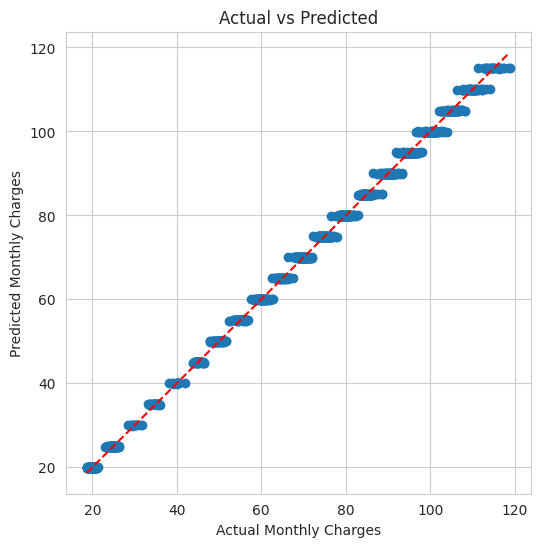

In [235]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test_reg, y_pred_reg)
plt.xlabel("Actual Monthly Charges")
plt.ylabel("Predicted Monthly Charges")
plt.title("Actual vs Predicted")
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'r--')
plt.show()

In [236]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 0.7882761056097962
Mean Squared Error (MSE): 1.0983132041712773
Root Mean Squared Error (RMSE): 1.0480043912938901
R² Score: 0.9987868964115143


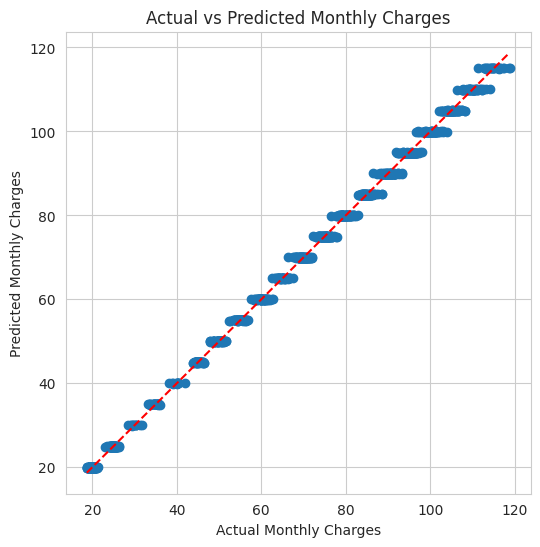

In [237]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test_reg, y_pred_reg)
plt.xlabel("Actual Monthly Charges")
plt.ylabel("Predicted Monthly Charges")
plt.title("Actual vs Predicted Monthly Charges")

plt.plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()],
    'r--'
)

plt.show()

In [238]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluation
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 0.7882761056097962
Mean Squared Error: 1.0983132041712773
Root Mean Squared Error: 1.0480043912938901
R² Score: 0.9987868964115143


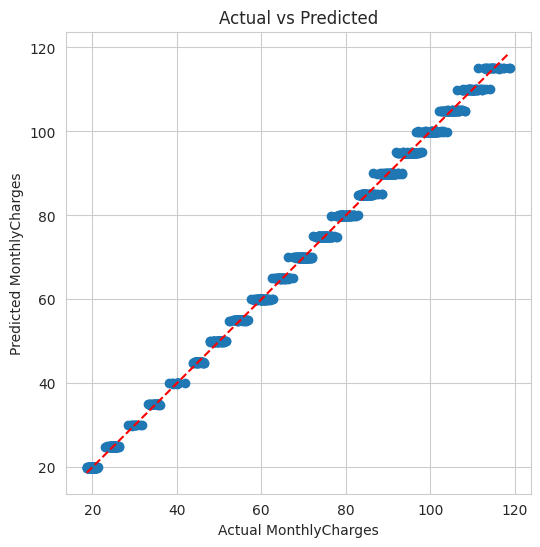

In [239]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test_reg, y_pred_reg)
plt.xlabel("Actual MonthlyCharges")
plt.ylabel("Predicted MonthlyCharges")
plt.title("Actual vs Predicted")
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'r--')
plt.show()

In [240]:
from sklearn.linear_model import LogisticRegression

clf_model = LogisticRegression(max_iter=1000)
clf_model.fit(X_train_clf, y_train_clf)

y_pred_clf = clf_model.predict(X_test_clf)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [241]:
print(X_train_clf.select_dtypes(include=['object']).columns)

Index([], dtype='object')


In [242]:
from sklearn.model_selection import train_test_split

# Regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

In [243]:
# Remove customerID
if 'customerID' in X.columns:
    X = X.drop('customerID', axis=1)

In [244]:
# Convert categorical columns into numbers
X = pd.get_dummies(X, drop_first=True)

In [245]:
from sklearn.model_selection import train_test_split

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y_clf,
    test_size=0.2,
    random_state=42
)

In [246]:
from sklearn.linear_model import LogisticRegression

clf_model = LogisticRegression(max_iter=1000)

clf_model.fit(X_train_clf, y_train_clf)

y_pred_clf = clf_model.predict(X_test_clf)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [247]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy :", accuracy_score(y_test_clf, y_pred_clf))
print("Precision:", precision_score(y_test_clf, y_pred_clf))
print("Recall   :", recall_score(y_test_clf, y_pred_clf))
print("F1 Score :", f1_score(y_test_clf, y_pred_clf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_clf, y_pred_clf))

Accuracy : 0.978708303761533
Precision: 0.9880597014925373
Recall   : 0.9678362573099415
F1 Score : 0.9778434268833087

Confusion Matrix:
[[717   8]
 [ 22 662]]


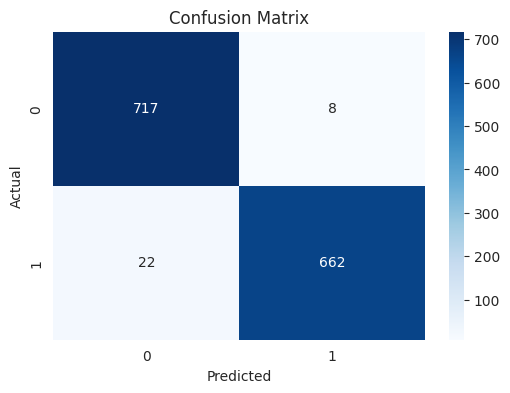

In [248]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_clf, y_pred_clf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [249]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test_clf, y_pred_clf))
print("Precision:", precision_score(y_test_clf, y_pred_clf))
print("Recall   :", recall_score(y_test_clf, y_pred_clf))
print("F1 Score :", f1_score(y_test_clf, y_pred_clf))

Accuracy : 0.978708303761533
Precision: 0.9880597014925373
Recall   : 0.9678362573099415
F1 Score : 0.9778434268833087


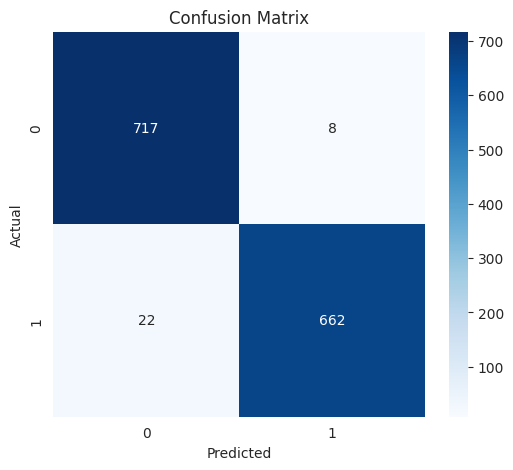

In [250]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_clf, y_pred_clf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [251]:
from sklearn.metrics import classification_report

print(classification_report(y_test_clf, y_pred_clf))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       725
           1       0.99      0.97      0.98       684

    accuracy                           0.98      1409
   macro avg       0.98      0.98      0.98      1409
weighted avg       0.98      0.98      0.98      1409



In [252]:
# ============================
# Task 1: Decision Tree Baseline
# ============================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Train Decision Tree (default parameters)
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train_clf, y_train_clf)

# Predictions
train_pred = dt_baseline.predict(X_train_clf)
test_pred = dt_baseline.predict(X_test_clf)

# Accuracy
train_acc = accuracy_score(y_train_clf, train_pred)
test_acc = accuracy_score(y_test_clf, test_pred)

print("Decision Tree (Baseline)")
print("-" * 30)
print(f"Training Accuracy : {train_acc:.4f}")
print(f"Testing Accuracy  : {test_acc:.4f}")

Decision Tree (Baseline)
------------------------------
Training Accuracy : 1.0000
Testing Accuracy  : 0.9752


In [253]:
# ============================
# Task 2: Controlled Decision Tree
# ============================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Decision Tree with controlled depth
dt_controlled = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)

dt_controlled.fit(X_train_clf, y_train_clf)

# Predictions
train_pred_ctrl = dt_controlled.predict(X_train_clf)
test_pred_ctrl = dt_controlled.predict(X_test_clf)

# Accuracy
train_acc_ctrl = accuracy_score(y_train_clf, train_pred_ctrl)
test_acc_ctrl = accuracy_score(y_test_clf, test_pred_ctrl)

print("Controlled Decision Tree")
print("-" * 30)
print(f"Training Accuracy : {train_acc_ctrl:.4f}")
print(f"Testing Accuracy  : {test_acc_ctrl:.4f}")

Controlled Decision Tree
------------------------------
Training Accuracy : 0.9679
Testing Accuracy  : 0.9624


In [254]:
# ============================
# Task 3: Gini vs Entropy
# ============================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# Gini model
dt_gini = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)
dt_gini.fit(X_train_clf, y_train_clf)

# Entropy model
dt_entropy = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)
dt_entropy.fit(X_train_clf, y_train_clf)

# Predictions
gini_pred = dt_gini.predict(X_test_clf)
entropy_pred = dt_entropy.predict(X_test_clf)

# Accuracy
gini_acc = accuracy_score(y_test_clf, gini_pred)
entropy_acc = accuracy_score(y_test_clf, entropy_pred)

# Comparison table
comparison = pd.DataFrame({
    "Criterion": ["Gini", "Entropy"],
    "Test Accuracy": [gini_acc, entropy_acc]
})

print(comparison)

  Criterion  Test Accuracy
0      Gini       0.975160
1   Entropy       0.975869


In [255]:
# ==========================================
# Task 4: Ensemble Models
# Random Forest & Gradient Boosting
# ==========================================

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train_clf, y_train_clf)

rf_pred = rf_model.predict(X_test_clf)
rf_acc = accuracy_score(y_test_clf, rf_pred)

# Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_clf, y_train_clf)

gb_pred = gb_model.predict(X_test_clf)
gb_acc = accuracy_score(y_test_clf, gb_pred)

# Results
ensemble_results = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting"],
    "Test Accuracy": [rf_acc, gb_acc]
})

print(ensemble_results)

               Model  Test Accuracy
0      Random Forest       0.973031
1  Gradient Boosting       0.977999


In [256]:
# ==========================================
# Task 5: Feature Ablation
# ==========================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Baseline Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_clf, y_train_clf)

baseline_acc = accuracy_score(y_test_clf, rf.predict(X_test_clf))
print(f"Baseline Accuracy: {baseline_acc:.4f}")

# Feature Importance
importances = rf.feature_importances_

feature_importance = (
    pd.DataFrame({
        "Feature": X_train_clf.columns,
        "Importance": importances
    })
    .sort_values(by="Importance", ascending=False)
)

print("\nTop 10 Important Features:")
print(feature_importance.head(10))

# Remove the most important feature
top_feature = feature_importance.iloc[0]["Feature"]

print(f"\nRemoving Feature: {top_feature}")

X_train_drop = X_train_clf.drop(columns=[top_feature])
X_test_drop = X_test_clf.drop(columns=[top_feature])

rf_drop = RandomForestClassifier(random_state=42)
rf_drop.fit(X_train_drop, y_train_clf)

drop_acc = accuracy_score(y_test_clf, rf_drop.predict(X_test_drop))

print(f"Accuracy after removing '{top_feature}': {drop_acc:.4f}")

Baseline Accuracy: 0.9730

Top 10 Important Features:
                                 Feature  Importance
9            InternetService_Fiber optic    0.298102
2                           TotalCharges    0.113440
20                       StreamingTV_Yes    0.055901
6                       PhoneService_Yes    0.054543
22                   StreamingMovies_Yes    0.050792
7         MultipleLines_No phone service    0.046822
8                      MultipleLines_Yes    0.045230
13      OnlineBackup_No internet service    0.040323
1                                 tenure    0.036675
15  DeviceProtection_No internet service    0.032008

Removing Feature: InternetService_Fiber optic
Accuracy after removing 'InternetService_Fiber optic': 0.9042


In [257]:
# ==========================================
# Task 6: Cross Validation
# ==========================================

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np

cv_model = LogisticRegression(max_iter=1000)

cv_scores = cross_val_score(
    cv_model,
    X_train_clf,
    y_train_clf,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:")
print(cv_scores)

print(f"\nMean Accuracy: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation: {np.std(cv_scores):.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Cross Validation Scores:
[0.97959184 0.97426797 0.98314108 0.98047915 0.98134991]

Mean Accuracy: 0.9798
Standard Deviation: 0.0030


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [258]:
# ==========================================
# Task 6: Hyperparameter Tuning with GridSearchCV
# ==========================================

from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Build Pipeline
pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

# Parameter Grid
param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [5, 10, None],
    'randomforestclassifier__min_samples_leaf': [1, 5]
}

# Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Grid Search
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

# Fit Model
grid.fit(X_train_clf, y_train_clf)

# Best Results
print("Best Parameters:")
print(grid.best_params_)

print("\nBest ROC-AUC:")
print(round(grid.best_score_, 4))

Best Parameters:
{'randomforestclassifier__max_depth': None, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__n_estimators': 200}

Best ROC-AUC:
0.9985


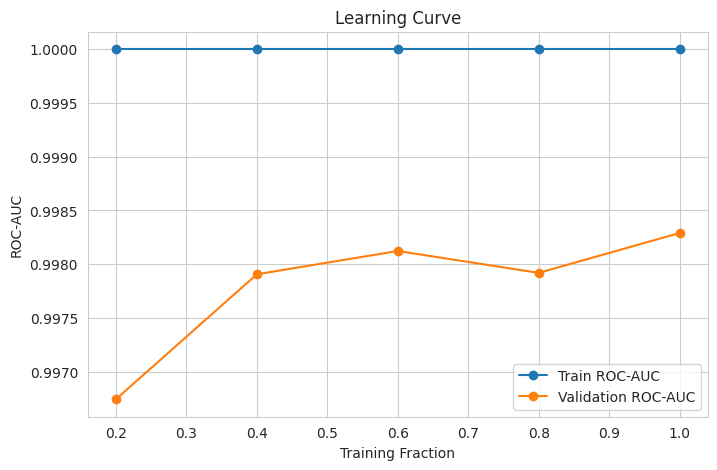

In [259]:
# ==========================================
# Task 7: Manual Learning Curve
# ==========================================

from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

fractions = [0.2, 0.4, 0.6, 0.8, 1.0]

train_scores = []
validation_scores = []

best_model = grid.best_estimator_

for frac in fractions:

    n = int(len(X_train_clf) * frac)

    X_small = X_train_clf.iloc[:n]
    y_small = y_train_clf.iloc[:n]

    best_model.fit(X_small, y_small)

    train_prob = best_model.predict_proba(X_small)[:, 1]
    val_prob = best_model.predict_proba(X_test_clf)[:, 1]

    train_scores.append(roc_auc_score(y_small, train_prob))
    validation_scores.append(roc_auc_score(y_test_clf, val_prob))

plt.figure(figsize=(8,5))
plt.plot(fractions, train_scores, marker='o', label='Train ROC-AUC')
plt.plot(fractions, validation_scores, marker='o', label='Validation ROC-AUC')

plt.xlabel("Training Fraction")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

In [260]:
comparison = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Controlled Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        0.978708303761533,
        test_acc,
        test_acc_ctrl,
        rf_acc,
        gb_acc
    ]
}

comparison_df = pd.DataFrame(comparison)

print(comparison_df.sort_values(by="Accuracy", ascending=False))

                      Model  Accuracy
0       Logistic Regression  0.978708
4         Gradient Boosting  0.977999
1             Decision Tree  0.975160
3             Random Forest  0.973031
2  Controlled Decision Tree  0.962385


In [261]:
# ==========================================
# Task 4b: Feature Ablation Study
# ==========================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# Train Random Forest
rf_full = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_full.fit(X_train_clf, y_train_clf)

# ROC-AUC of full model
full_probs = rf_full.predict_proba(X_test_clf)[:, 1]
full_auc = roc_auc_score(y_test_clf, full_probs)

# Feature importance
importance_df = pd.DataFrame({
    "Feature": X_train_clf.columns,
    "Importance": rf_full.feature_importances_
}).sort_values("Importance")

print("5 Least Important Features")
print(importance_df.head())

# Remove the 5 least important features
remove_features = importance_df.head(5)["Feature"].tolist()

X_train_reduced = X_train_clf.drop(columns=remove_features)
X_test_reduced = X_test_clf.drop(columns=remove_features)

# Train reduced model
rf_reduced = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_reduced.fit(X_train_reduced, y_train_clf)

reduced_probs = rf_reduced.predict_proba(X_test_reduced)[:, 1]
reduced_auc = roc_auc_score(y_test_clf, reduced_probs)

print("\nFull Model ROC-AUC :", round(full_auc, 4))
print("Reduced Model ROC-AUC :", round(reduced_auc, 4))

5 Least Important Features
                                  Feature  Importance
26  PaymentMethod_Credit card (automatic)    0.001823
3                             gender_Male    0.001989
5                          Dependents_Yes    0.002248
4                             Partner_Yes    0.002579
23                      Contract_One year    0.002837

Full Model ROC-AUC : 0.9978
Reduced Model ROC-AUC : 0.9982


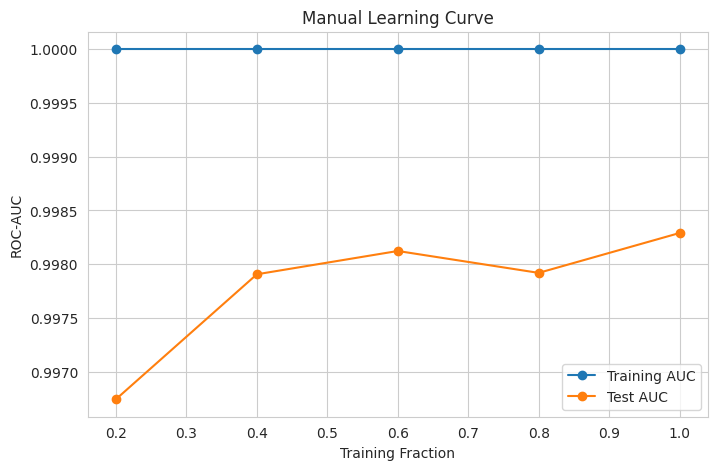


Training Fraction | Training AUC | Test AUC
0.2		 1.0000		 0.9967
0.4		 1.0000		 0.9979
0.6		 1.0000		 0.9981
0.8		 1.0000		 0.9979
1.0		 1.0000		 0.9983


In [262]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

fractions = [0.2, 0.4, 0.6, 0.8, 1.0]

train_auc = []
test_auc = []

best_pipeline = grid.best_estimator_

for f in fractions:

    n = int(f * len(X_train_clf))

    X_small = X_train_clf.iloc[:n]
    y_small = y_train_clf.iloc[:n]

    best_pipeline.fit(X_small, y_small)

    train_pred = best_pipeline.predict_proba(X_small)[:, 1]
    test_pred = best_pipeline.predict_proba(X_test_clf)[:, 1]

    train_auc.append(roc_auc_score(y_small, train_pred))
    test_auc.append(roc_auc_score(y_test_clf, test_pred))

plt.figure(figsize=(8,5))
plt.plot(fractions, train_auc, marker='o', label='Training AUC')
plt.plot(fractions, test_auc, marker='o', label='Test AUC')
plt.xlabel("Training Fraction")
plt.ylabel("ROC-AUC")
plt.title("Manual Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

print("\nTraining Fraction | Training AUC | Test AUC")
for f, tr, te in zip(fractions, train_auc, test_auc):
    print(f"{f:.1f}\t\t {tr:.4f}\t\t {te:.4f}")

In [263]:
%who

DecisionTreeClassifier	 GradientBoostingClassifier	 GridSearchCV	 IQR	 LinearRegression	 LogisticRegression	 Q1	 Q3	 RandomForestClassifier	 
SimpleImputer	 StandardScaler	 StratifiedKFold	 X	 X_small	 X_test_clf	 X_test_drop	 X_test_reduced	 X_test_reg	 
X_train_clf	 X_train_drop	 X_train_reduced	 X_train_reg	 accuracy_score	 baseline_acc	 best_model	 best_pipeline	 classification_report	 
clf_model	 cm	 col	 comparison	 comparison_df	 confusion_matrix	 corr_copy	 correlation_matrix	 cross_val_score	 
cv	 cv_model	 cv_scores	 df	 difference	 drop_acc	 dt_baseline	 dt_controlled	 dt_entropy	 
dt_gini	 duplicate_count	 ensemble_results	 entropy_acc	 entropy_pred	 f	 f1_score	 feature_importance	 frac	 
fractions	 full_auc	 full_probs	 gb_acc	 gb_model	 gb_pred	 gini_acc	 gini_pred	 grid	 
group	 high_missing	 highest_mean	 highest_pair	 highest_skew_col	 highest_std	 highest_value	 importance_df	 importances	 
joblib	 lower	 mae	 make_pipeline	 mean_absolute_error	 mean_squared_error	 m

In [264]:
print([v for v in globals() if "y" in v.lower()])

['get_ipython', 'memory_before', 'memory_after', 'corr_copy', 'y_reg', 'y_clf', 'y_train_reg', 'y_test_reg', 'y_train_clf', 'y_test_clf', 'y_pred_clf', 'accuracy_score', 'dt_entropy', 'entropy_pred', 'entropy_acc', 'y_small', 'y_pred_reg']


In [265]:
%who

DecisionTreeClassifier	 GradientBoostingClassifier	 GridSearchCV	 IQR	 LinearRegression	 LogisticRegression	 Q1	 Q3	 RandomForestClassifier	 
SimpleImputer	 StandardScaler	 StratifiedKFold	 X	 X_small	 X_test_clf	 X_test_drop	 X_test_reduced	 X_test_reg	 
X_train_clf	 X_train_drop	 X_train_reduced	 X_train_reg	 accuracy_score	 baseline_acc	 best_model	 best_pipeline	 classification_report	 
clf_model	 cm	 col	 comparison	 comparison_df	 confusion_matrix	 corr_copy	 correlation_matrix	 cross_val_score	 
cv	 cv_model	 cv_scores	 df	 difference	 drop_acc	 dt_baseline	 dt_controlled	 dt_entropy	 
dt_gini	 duplicate_count	 ensemble_results	 entropy_acc	 entropy_pred	 f	 f1_score	 feature_importance	 frac	 
fractions	 full_auc	 full_probs	 gb_acc	 gb_model	 gb_pred	 gini_acc	 gini_pred	 grid	 
group	 high_missing	 highest_mean	 highest_pair	 highest_skew_col	 highest_std	 highest_value	 importance_df	 importances	 
joblib	 lower	 mae	 make_pipeline	 mean_absolute_error	 mean_squared_error	 m

In [266]:
print([v for v in globals() if "pred" in v.lower()])

['y_pred_clf', 'train_pred', 'test_pred', 'train_pred_ctrl', 'test_pred_ctrl', 'gini_pred', 'entropy_pred', 'rf_pred', 'gb_pred', 'y_pred_reg']


In [267]:
print(type(best_model))

<class 'sklearn.pipeline.Pipeline'>


In [268]:
print(best_model)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('randomforestclassifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])


In [277]:
from sklearn.linear_model import LinearRegression

reg_model = LinearRegression()

reg_model.fit(X_train_reg, y_train_reg)

y_pred_reg = reg_model.predict(X_test_reg)

print("Prediction created successfully!")

Prediction created successfully!


In [276]:
print(X_train_reg.columns)

Index(['SeniorCitizen', 'tenure', 'TotalCharges', 'gender_Male', 'Partner_Yes',
       'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No internet service',
       'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


In [275]:
print(X_train_reg.dtypes)


SeniorCitizen                              int64
tenure                                     int64
TotalCharges                             float64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes                             bool
StreamingTV_No internet service             bool
StreamingTV_Yes     

In [274]:
# Remove columns that should not be features
X_train_reg = X_train_reg.drop(columns=["customerID", "Churn"])
X_test_reg = X_test_reg.drop(columns=["customerID", "Churn"])

# Convert categorical columns into numeric
X_train_reg = pd.get_dummies(X_train_reg, drop_first=True)
X_test_reg = pd.get_dummies(X_test_reg, drop_first=True)

# Make sure both train and test have the same columns
X_train_reg, X_test_reg = X_train_reg.align(X_test_reg, join="left", axis=1, fill_value=0)

In [278]:
from sklearn.linear_model import LinearRegression

reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)

y_pred_reg = reg_model.predict(X_test_reg)

print("Regression model trained successfully!")

Regression model trained successfully!


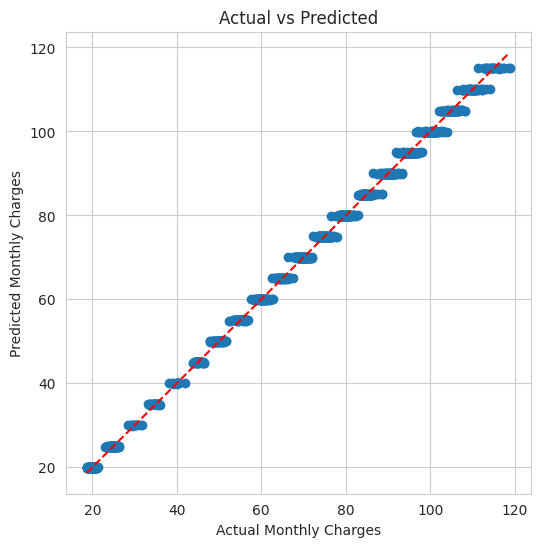

In [271]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test_reg, y_pred_reg)
plt.xlabel("Actual Monthly Charges")
plt.ylabel("Predicted Monthly Charges")
plt.title("Actual vs Predicted")
plt.plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()],
    'r--'
)
plt.show()